# Stage 6 — Player-Level Clutch Performance Index (CPI)

**Pipeline position:** Stage 5 `clutch_values_signed.parquet` → **Stage 6** → `cpi_signed_full.parquet` → Stage 6b

Aggregates the clutch values `V` (league points) to players:

```
CPI(p) = (m / n_p) · Σ V(aᵢ)          over the player's actions in the season
```

`m = 56` is the median number of actions a player records in one appearance, so one CPI unit is one appearance's
worth of opportunity. Players with at least 700 actions are ranked.

**Also produced**

- **Score-state sub-ratings** — CPI while chasing / level / protecting.
- **Stakes exposure** — how much high-stakes play each player actually had.
- **Split-half stability** — odd vs even gameweeks, Spearman–Brown corrected, for CPI and two baselines on identical data:
  unweighted action values, and action values weighted by the one-sided index.

## 0. Setup

In [1]:
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
print('Libraries loaded.')

Libraries loaded.


In [2]:
# Repository root (the notebooks live one level below it)
BASE_DIR = Path('..') if Path.cwd().name in ('pipeline-stages', 'feature-engineering') else Path('.')

CLUTCH_PATH  = BASE_DIR / 'data' / 'clutch_values_signed.parquet'
PLAYERS_PATH = BASE_DIR / 'WyScout' / 'players.json'
TEAMS_PATH   = BASE_DIR / 'WyScout' / 'teams.json'
OUTPUT_PATH  = BASE_DIR / 'data' / 'cpi_signed_full.parquet'

STAGE6_DIR = BASE_DIR / 'stage6_cpi'
PLOTS_DIR  = STAGE6_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

MIN_ACTIONS   = 700      # players ranked
MIN_STATE     = 200      # actions needed for a score-state sub-rating
SCORE_STATES  = ['chasing', 'level', 'protecting']
POSITIONS     = ['forward', 'midfielder', 'defender', 'goalkeeper']
HIGH_LEVERAGE = 2.0      # a moment with at least twice the average stakes

print('Configuration ready.')
for p in (CLUTCH_PATH, PLAYERS_PATH, TEAMS_PATH):
    print(f"  {'OK     ' if p.exists() else 'MISSING'} {p}")

Configuration ready.
  OK      ../data/clutch_values_signed.parquet
  OK      ../WyScout/players.json
  OK      ../WyScout/teams.json


## 1. Load

Stage 5 values for every action, plus player and team names for readable tables. Names are for display only.

In [3]:
COLS = ['game_id', 'team_id', 'player_id', 'league_country', 'gameweek', 'minute',
        'score_state', 'position_group', 'action_type',
        'is_goal_action', 'vaep_value', 'L_plus', 'L_minus', 'V', 'V_sym']
df = pd.read_parquet(CLUTCH_PATH, columns=COLS)
print(f"Actions: {len(df):,}   players: {df['player_id'].nunique():,}   matches: {df['game_id'].nunique():,}")

BS_U = '\\' + 'u'   # one backslash followed by 'u'


def clean(s):
    """Wyscout stores some accented names as literal escapes ('Su\\u00e1rez'); decode them."""
    if not isinstance(s, str) or BS_U not in s:
        return s
    try:
        return s.encode('latin-1').decode('unicode_escape')
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s


with open(PLAYERS_PATH, encoding='utf-8') as f:
    players = json.load(f)
names = pd.DataFrame({
    'player_id': [int(p.get('wyId', p.get('playerId'))) for p in players],
    'name': [p.get('shortName') or f"{p.get('firstName', '')} {p.get('lastName', '')}".strip()
             for p in players],
}).drop_duplicates('player_id').set_index('player_id')['name'].map(clean)

teams = pd.Series(dtype=object, name='team')
if TEAMS_PATH.exists():
    with open(TEAMS_PATH, encoding='utf-8') as f:
        teams = pd.Series({int(t['wyId']): clean(t.get('name')) for t in json.load(f)}, name='team')
print(f'Names: {len(names):,} players, {len(teams):,} teams '
      f'(escaped names left: {names.str.contains(BS_U, regex=False, na=False).sum()})')

Actions: 2,831,756   players: 2,568   matches: 1,826
Names: 3,603 players, 142 teams (escaped names left: 0)


## 2. The Scale Constant `m`

`m` is the median number of actions a player makes in one appearance. It only rescales CPI — rankings and
correlations do not depend on it.

In [4]:
M = int(round(df.groupby(['game_id', 'player_id']).size().median()))
print(f'm = {M} actions per appearance (median)')

m = 56 actions per appearance (median)


## 3. Aggregate to Players

| Column | Definition |
|---|---|
| `CPI` | `(m / n_p) · Σ V` — **primary** |
| `CPI_sym` | same aggregation of `V_sym` (one-sided index) — baseline |
| `VAEP` | same aggregation of the unweighted value — baseline |
| `CPI_chasing` / `_level` / `_protecting` | CPI over the actions in that score state; published if the player has enough actions in it |
| `mean_leverage` | mean of `L̃ = (L⁺ + L⁻) / mean(L⁺ + L⁻)` over the player's actions — `L̃ = 1` is an average moment |
| `high_leverage_share` | share of the player's actions with `L̃ ≥ 2` |
| `rank` | overall rank (qualified players) |
| `rank_in_position` | rank within position group — the ranking used for reporting |

**Hard gates:** the player totals add back exactly to the season total, and every qualified player has a finite CPI.

In [5]:
def aggregate(d, m, min_actions, min_state):
    lev = d['L_plus'] + d['L_minus']
    d = d.assign(Ltilde=lev / lev.mean())
    d = d.assign(is_high=d['Ltilde'] >= HIGH_LEVERAGE)

    out = d.groupby('player_id').agg(
        n_actions=('V', 'size'), n_matches=('game_id', 'nunique'), goals=('is_goal_action', 'sum'),
        V_sum=('V', 'sum'), V_sym_sum=('V_sym', 'sum'), vaep_sum=('vaep_value', 'sum'),
        position_group=('position_group', 'first'), league=('league_country', 'first'),
        mean_leverage=('Ltilde', 'mean'), high_leverage_share=('is_high', 'mean'))

    out['CPI']     = m * out['V_sum']     / out['n_actions']
    out['CPI_sym'] = m * out['V_sym_sum'] / out['n_actions']
    out['VAEP']    = m * out['vaep_sum']  / out['n_actions']

    st = d.groupby(['player_id', 'score_state'])['V'].agg(['sum', 'size']).unstack('score_state')
    for s in SCORE_STATES:
        n_s = st[('size', s)].reindex(out.index).fillna(0).astype(int)
        out[f'n_{s}']   = n_s
        out[f'CPI_{s}'] = (m * st[('sum', s)].reindex(out.index) / n_s).where(n_s >= min_state)

    main_team = (d.groupby(['player_id', 'team_id']).size().rename('k').reset_index()
                   .sort_values('k', ascending=False).drop_duplicates('player_id')
                   .set_index('player_id')['team_id'])
    out['team_id'] = main_team
    out['name']    = names.reindex(out.index)
    out['team']    = out['team_id'].map(teams)

    out['qualified'] = out['n_actions'] >= min_actions
    q = out['qualified']
    out.loc[q, 'rank'] = out.loc[q, 'CPI'].rank(ascending=False, method='min')
    out.loc[q, 'rank_in_position'] = (out[q].groupby('position_group')['CPI']
                                      .rank(ascending=False, method='min'))
    return out


out = aggregate(df, M, MIN_ACTIONS, MIN_STATE)
gates = [
    ('player totals add back to the season total',
     np.isclose(out['V_sum'].sum(), df['V'].sum(), rtol=0, atol=1e-6) and out['n_actions'].sum() == len(df)),
    ('every qualified player has a finite CPI',
     bool(np.isfinite(out.loc[out['qualified'], 'CPI']).all())),
]
print(f"{out['qualified'].sum():,} of {len(out):,} players qualify (n_p >= {MIN_ACTIONS})")
for name, ok in gates:
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
assert all(ok for _, ok in gates), 'aggregation gates failed — stop here.'
cpi = out

1,589 of 2,568 players qualify (n_p >= 700)
  [PASS] player totals add back to the season total
  [PASS] every qualified player has a finite CPI


## 4. Rankings

Top players overall and within each position.

In [6]:
SHOW = ['rank', 'name', 'team', 'position_group', 'n_actions', 'goals', 'CPI', 'CPI_sym', 'VAEP',
        'CPI_chasing', 'CPI_level', 'CPI_protecting', 'mean_leverage']

q = cpi[cpi['qualified']].sort_values('rank')
print(f"TOP 20 overall\n{'=' * 110}")
print(q[SHOW].head(20).round(4).to_string(index=False))

for pos in POSITIONS:
    top = q[q['position_group'] == pos].nsmallest(5, 'rank_in_position')
    print(f"\nTop 5 {pos}s:")
    print(top[['rank_in_position', 'name', 'team', 'CPI', 'CPI_protecting']].round(4).to_string(index=False))

TOP 20 overall
 rank            name              team position_group  n_actions  goals    CPI  CPI_sym   VAEP  CPI_chasing  CPI_level  CPI_protecting  mean_leverage
  1.0       M. Icardi    Internazionale        forward       1003     29 0.6178   0.7018 1.0554          NaN     0.6793          0.4321         1.0443
  2.0       E. Cavani               PSG        forward        940     28 0.4969   0.5631 1.0904          NaN     0.6878          0.2040         0.8772
  3.0     C. Immobile             Lazio        forward       1525     29 0.4301   0.4795 0.8452          NaN     0.4906          0.3513         0.9493
  4.0     A. Kramarić        Hoffenheim        forward       1541     13 0.4127   0.4897 0.5020       0.1863     0.7932          0.0405         0.9787
  5.0        J. Vardy    Leicester City        forward       1257     20 0.3820   0.3903 0.6092       0.2571     0.6995         -0.0573         1.0315
  6.0     N. Petersen          Freiburg        forward       1386     15 0.3773

In [7]:
rows = []
for pos in POSITIONS:
    s = q[q['position_group'] == pos]
    rows.append({'position': pos, 'players': len(s),
                 'mean_CPI': s['CPI'].mean(), 'median_CPI': s['CPI'].median(),
                 'pct_positive': (s['CPI'] > 0).mean() * 100})
position_summary = pd.DataFrame(rows)
print('Qualified players only:')
print(position_summary.round(4).to_string(index=False))
position_summary.to_csv(STAGE6_DIR / 'position_summary.csv', index=False)

Qualified players only:
  position  players  mean_CPI  median_CPI  pct_positive
   forward      287    0.1313      0.1118       91.6376
midfielder      598    0.0918      0.0826       99.8328
  defender      609    0.0787      0.0753       99.5074
goalkeeper       95   -0.1384     -0.1424        1.0526


## 5. Split-Half Stability

Each player's matches are split into **odd** and **even** gameweeks, the metric is computed on each half, and the two halves are rank-correlated (Spearman ρ). Because each half holds only half the data, the full-season reliability is estimated with the Spearman–Brown correction:

```
ρ_SB = 2ρ / (1 + ρ)
```

The signed CPI and its two baselines are measured on **identical players and actions**, so any difference is due to the weighting alone. A player enters if each half has at least half the playing-time threshold (350 actions).

In [8]:
def split_half(d, min_half):
    d = d[d['gameweek'] > 0]
    d = d.assign(half=np.where(d['gameweek'] % 2 == 1, 'odd', 'even'))
    g = d.groupby(['player_id', 'half']).agg(n=('V', 'size'), signed=('V', 'sum'),
                                              symmetric=('V_sym', 'sum'), unweighted=('vaep_value', 'sum'))
    for col in ['signed', 'symmetric', 'unweighted']:
        g[col] = g[col] / g['n']
    wide = g.unstack('half')
    keep = (wide[('n', 'odd')] >= min_half) & (wide[('n', 'even')] >= min_half)
    return wide[keep]


def reliability(wide, cols=('unweighted', 'symmetric', 'signed')):
    out = {'players': len(wide)}
    for c in cols:
        rho = wide[(c, 'odd')].corr(wide[(c, 'even')], method='spearman')
        out[c] = 2 * rho / (1 + rho)
    return out


wide = split_half(df, MIN_ACTIONS / 2)
pos  = cpi['position_group'].reindex(wide.index)
stab_rows = [{'group': 'all', **reliability(wide)}]
for p in POSITIONS:
    stab_rows.append({'group': p, **reliability(wide[pos == p])})
stability = pd.DataFrame(stab_rows)
print('Spearman-Brown split-half reliability (odd vs even gameweeks):')
print(stability.round(3).to_string(index=False))
stability.to_csv(STAGE6_DIR / 'split_half_stability.csv', index=False)

Spearman-Brown split-half reliability (odd vs even gameweeks):
     group  players  unweighted  symmetric  signed
       all     1497       0.561      0.488   0.506
   forward      261       0.478      0.304   0.333
midfielder      564       0.404      0.337   0.330
  defender      581       0.368      0.272   0.337
goalkeeper       91       0.810      0.661   0.544


## 6. Figures

1. **CPI by position.**
2. **Split-half reliability** — CPI against its two baselines, by position.

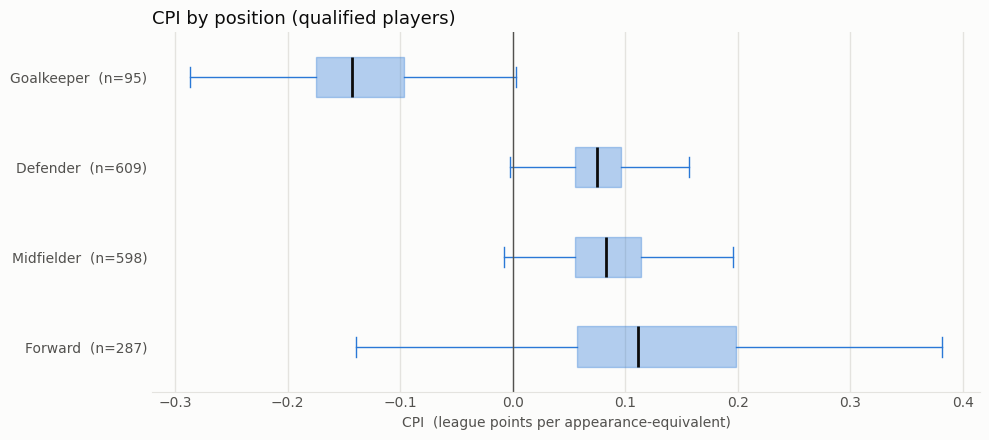

Saved: ../stage6_cpi/plots/cpi_by_position.png


In [9]:
INK, INK_2, GRID, SURFACE = '#0b0b0b', '#52514e', '#e4e3df', '#fcfcfb'


def style(ax):
    ax.set_facecolor(SURFACE)
    ax.set_axisbelow(True)
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)
    ax.spines['bottom'].set_color(GRID)
    ax.tick_params(colors=INK_2, length=0)


data = [q.loc[q['position_group'] == p, 'CPI'].values for p in POSITIONS]

fig, ax = plt.subplots(figsize=(10, 4.5), facecolor=SURFACE)
bp = ax.boxplot(data, vert=False, widths=0.45, showfliers=False, patch_artist=True,
                medianprops=dict(color=INK, lw=2),
                boxprops=dict(facecolor='#2a78d6', alpha=0.35, edgecolor='#2a78d6'),
                whiskerprops=dict(color='#2a78d6'), capprops=dict(color='#2a78d6'))
ax.axvline(0, color=INK_2, lw=1)
ax.set_yticks(range(1, len(POSITIONS) + 1))
ax.set_yticklabels([f"{p.title()}  (n={len(v)})" for p, v in zip(POSITIONS, data)], color=INK)
ax.set_xlabel('CPI  (league points per appearance-equivalent)', color=INK_2)
ax.set_title('CPI by position (qualified players)', loc='left', fontsize=13, color=INK)
ax.grid(axis='x', color=GRID, lw=1, ls='-')
style(ax)
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'cpi_by_position.png', dpi=150, bbox_inches='tight', facecolor=SURFACE)
plt.show()
print(f"Saved: {PLOTS_DIR / 'cpi_by_position.png'}")

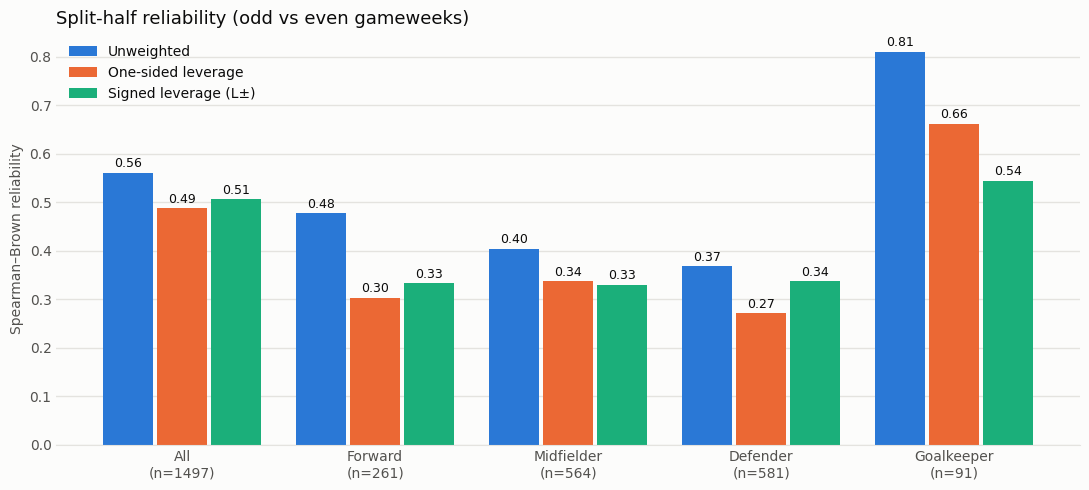

Saved: ../stage6_cpi/plots/split_half_reliability.png


In [10]:
# Same three series and colours as the Stage 5 figure; every bar carries its value.
SERIES = [('unweighted', 'Unweighted',           '#2a78d6'),
          ('symmetric',  'One-sided leverage',   '#eb6834'),
          ('signed',     'Signed leverage (L±)', '#1baf7a')]
GROUPS = ['all'] + POSITIONS

s = stability.set_index('group').reindex(GROUPS)
fig, ax = plt.subplots(figsize=(11, 5), facecolor=SURFACE)
x, w = np.arange(len(GROUPS)), 0.26
for j, (col, label, colour) in enumerate(SERIES):
    xs = x + (j - 1) * (w + 0.02)
    ax.bar(xs, s[col], w, color=colour, label=label)
    for xi, v in zip(xs, s[col]):
        ax.annotate(f'{v:.2f}', (xi, max(v, 0)), xytext=(0, 4), textcoords='offset points',
                    ha='center', fontsize=9, color=INK)
ax.set_xticks(x)
ax.set_xticklabels([f"{g.title()}\n(n={int(n)})" for g, n in zip(GROUPS, s['players'])], color=INK)
ax.set_ylabel('Spearman–Brown reliability', color=INK_2)
ax.set_title('Split-half reliability (odd vs even gameweeks)', loc='left', fontsize=13, color=INK)
ax.legend(frameon=False, fontsize=10, labelcolor=INK)
ax.grid(axis='y', color=GRID, lw=1, ls='-')
style(ax)
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'split_half_reliability.png', dpi=150, bbox_inches='tight', facecolor=SURFACE)
plt.show()
print(f"Saved: {PLOTS_DIR / 'split_half_reliability.png'}")

## 7. Save

Every player is kept, with a `qualified` flag; rankings are published for qualified players only.

In [11]:
out = cpi.reset_index()
out.to_parquet(OUTPUT_PATH, index=False)
out[out['qualified']].sort_values('rank').to_csv(STAGE6_DIR / 'ranking_full.csv', index=False)
print(f"Saved: {OUTPUT_PATH}   ({len(out):,} players, {out['qualified'].sum():,} qualified)")
print(f'Tables:  {STAGE6_DIR}')

Saved: ../data/cpi_signed_full.parquet   (2,568 players, 1,589 qualified)
Tables:  ../stage6_cpi


**Next → Stage 6b:** per-position leaderboards with 95% intervals from resampling matches. **Stage 7:** validation tests.